# Detección de Plagio en Código Fuente

Pipeline completo para detectar plagio entre archivos `.c` y `.java` del dataset SOCO-2014.  
Combina embeddings semánticos (UniXcoder), métricas de similitud textual y un clasificador.

---

## 1. Carga de Archivos

In [181]:
from pathlib import Path
import pandas as pd

c_files = list(Path("soco-dataset/c").glob("*.c"))
java_files = list(Path("soco-dataset/java").glob("*.java"))
files = c_files + java_files

print(f"Archivos C: {len(c_files)} | Java: {len(java_files)} | Total: {len(files)}")

Archivos C: 79 | Java: 259 | Total: 338


## 2. Embeddings Semánticos con UniXcoder

Cargamos `microsoft/unixcoder-base` para generar representaciones densas del código fuente. Cada archivo se tokeniza y se promedia el último estado oculto como vector de embedding.

In [182]:
from transformers import AutoTokenizer, AutoModel
import torch

# Utilizar tokenizer y modelo de embedding UniXcoder
tokenizer = AutoTokenizer.from_pretrained("microsoft/unixcoder-base")
embedding_model = AutoModel.from_pretrained("microsoft/unixcoder-base")

print("Successfully imported tokenizer and model UNIXCODER")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Successfully imported tokenizer and model UNIXCODER


In [183]:
def tokenize_and_embed(filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        code = f.read()

    # Unixcoder pide un máximo de 512 tokens por archivo. Como existen
    # archivos con más tokens, se separan los 
    input_ids = tokenizer(code, add_special_tokens=False)["input_ids"]

    # Dividir en bloques de hasta 510 tokens (+ <s> y </s> = 512, límite de UniXcoder)
    chunk_size = 510

    # Indica qué rango de tokens se tomará en cuenta
    chunks = [input_ids[i:i + chunk_size] for i in range(0, len(input_ids), chunk_size)]

    chunk_embeddings = []
    chunk_lengths = []

    # Para cada chunk
    for chunk in chunks:
        ids = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]
        input_tensor = torch.tensor([ids])
        attention_mask = torch.ones_like(input_tensor)

        with torch.no_grad():
            outputs = embedding_model(input_ids=input_tensor, attention_mask=attention_mask)

        chunk_embeddings.append(outputs.last_hidden_state.mean(dim=1))
        chunk_lengths.append(len(chunk))

    # Promediar los embeddings de cada bloque, ponderando por su tamaño
    weights = torch.tensor(chunk_lengths, dtype=torch.float).unsqueeze(1)
    stacked = torch.cat(chunk_embeddings, dim=0)
    embedding = (stacked * weights).sum(dim=0, keepdim=True) / weights.sum()

    return embedding

In [184]:
from tqdm.notebook import tqdm
import numpy as np

def save_embeddings(files):
    embeddings = []
    for file in tqdm(files, desc="Generating embeddings", unit="file"):
        embeddings.append(tokenize_and_embed(file))
    return np.array(embeddings).squeeze(1)

In [185]:
embeddings = save_embeddings(files)

Generating embeddings:   0%|          | 0/338 [00:00<?, ?file/s]

## 3. Matriz de Similitud de Coseno

Calculamos la similitud coseno entre todos los pares de embeddings para obtener una medida de parecido semántico global entre archivos.

In [186]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)

## 4. Construcción de Pares y Ranking

Generamos todos los pares únicos de archivos, los ordenamos por similitud descendente y construimos el DataFrame base que alimentará el extractor de features.

In [187]:
def sort_similarities(files, embeddings, sim_matrix):
    pairs = []
    
    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            plagiarism = 0
            pairs.append((files[i], files[j], round(float(sim_matrix[i][j]), 4)))
    
    pairs.sort(key=lambda x: x[2], reverse=True)

    return pairs

In [188]:
def create_dataframe(pairs, num_of_pairs):
    data_frame = pd.DataFrame(
        pairs[:num_of_pairs],
        columns=["file1", "file2", "similarity"]
    )
    data_frame["file1"] = data_frame["file1"].apply(lambda x: x.name)
    data_frame["file2"] = data_frame["file2"].apply(lambda x: x.name)
    return data_frame

In [189]:
pairs = sort_similarities(files, embeddings, sim_matrix)

dataframe = create_dataframe(pairs, 60000)

display(dataframe.head(100))

,file1,file2,similarity
0,005.java,006.java,1.0000
1,015.java,023.java,0.9990
2,250.java,159.java,0.9944
3,024.java,016.java,0.9940
4,043.java,251.java,0.9932
...,...,...,...
95,031.c,025.c,0.9134
96,032.c,026.c,0.9134
97,009.c,045.c,0.9134
98,040.c,007.c,0.9132


## 5. Extracción de Features de Similitud Textual

Cargamos el ground truth real desde los archivos `.qrel` del dataset SOCO y calculamos múltiples métricas de similitud textual (Jaccard, Dice, Levenshtein, Jaro-Winkler, coseno BoW) para cada par de archivos.

In [190]:
import re
import math
import pandas as pd
import numpy as np
from collections import Counter
from pathlib import Path
from rapidfuzz.distance import Levenshtein as RapidLev
from rapidfuzz.distance import Jaro, JaroWinkler

def load_ground_truth():
    plagiarism_pairs = set()
    for qrel_path in ["soco-dataset/SOCO14-c.qrel", "soco-dataset/SOCO14-java.qrel"]:
        with open(qrel_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    a, b = parts
                    plagiarism_pairs.add((a, b))
                    plagiarism_pairs.add((b, a))
    return plagiarism_pairs

ground_truth = load_ground_truth()
print(f"Pares de plagio en ground truth: {len(ground_truth) // 2}")

Pares de plagio en ground truth: 110


In [191]:
def read_code(filename):
    for folder in ["soco-dataset/c", "soco-dataset/java"]:
        path = Path(folder) / filename
        if path.exists():
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                return f.read()
    return ""

def normalize_code(code):
    code = re.sub(r"//.*?\n|/\*.*?\*/", " ", code, flags=re.DOTALL)
    return re.sub(r"\s+", " ", code).strip().lower()

def tokenize(code):
    return re.findall(r"\w+", code)

def get_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

def jaccard(seq_a, seq_b):
    set_a, set_b = set(seq_a), set(seq_b)
    if not set_a and not set_b:
        return 1.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

def dice(seq_a, seq_b):
    set_a, set_b = set(seq_a), set(seq_b)
    if not set_a and not set_b:
        return 1.0
    inter = len(set_a & set_b)
    denom = len(set_a) + len(set_b)
    return 2 * inter / denom if denom > 0 else 0.0

def cosine_bow(tokens_a, tokens_b):
    ca, cb = Counter(tokens_a), Counter(tokens_b)
    vocab = set(ca) | set(cb)
    dot = sum(ca[w] * cb[w] for w in vocab)
    mag_a = math.sqrt(sum(v ** 2 for v in ca.values()))
    mag_b = math.sqrt(sum(v ** 2 for v in cb.values()))
    return dot / (mag_a * mag_b) if mag_a and mag_b else 0.0

print("Funciones de similitud definidas correctamente.")


Funciones de similitud definidas correctamente.


In [192]:
from tqdm.notebook import tqdm

# Parámetros
N_NEGATIVES = 12000  # negativos a samplear

# Métricas en escala 0-1
AVG_METRICS = [
    "jaccard_tokens", "jaccard_bigrams", "jaccard_trigrams",
    "dice", "levenshtein_ratio",
    "jaro", "jaro_winkler",
    "cosine_similarity", "embedding_cosine"
]

# Cachear tokens una sola vez por archivo
print("Preprocesando y cacheando archivos...")
all_files = set(dataframe["file1"]) | set(dataframe["file2"])
file_tokens_cache = {}
for fname in tqdm(all_files, desc="Tokenizando archivos"):
    code = normalize_code(read_code(fname))
    file_tokens_cache[fname] = tokenize(code)

def compute_features_cached(f1, f2, emb_cos):
    tokens1 = file_tokens_cache.get(f1, [])
    tokens2 = file_tokens_cache.get(f2, [])

    t1 = " ".join(tokens1[:1000])
    t2 = " ".join(tokens2[:1000])

    lev_dist = RapidLev.distance(t1, t2)
    max_len  = max(len(t1), len(t2))
    lev_ratio = 1.0 - (lev_dist / max_len) if max_len > 0 else 1.0

    return {
        "code1_id":          f1,
        "code2_id":          f2,
        "jaccard_tokens":    jaccard(tokens1, tokens2),
        "jaccard_bigrams":   jaccard(get_ngrams(tokens1, 2), get_ngrams(tokens2, 2)),
        "jaccard_trigrams":  jaccard(get_ngrams(tokens1, 3), get_ngrams(tokens2, 3)),
        "dice":              dice(tokens1, tokens2),
        "levenshtein_dist":  lev_dist,
        "levenshtein_ratio": lev_ratio,
        "jaro":              Jaro.similarity(t1, t2),
        "jaro_winkler":      JaroWinkler.similarity(t1, t2),
        "cosine_similarity": cosine_bow(tokens1, tokens2),
        "embedding_cosine":  round(float(emb_cos), 6),
    }

# ── Calcular features para todos los pares ─────────────────────────────────
print("\nCalculando features para todos los pares...")
rows = []
for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Procesando pares"):
    record = compute_features_cached(row["file1"], row["file2"], row["similarity"])
    rows.append(record)

df_features = pd.DataFrame(rows)

# ── Promedio de similitud (informativo) y label desde el ground truth (.qrel) ──
df_features["similarity_avg"] = df_features[AVG_METRICS].mean(axis=1)
df_features["label"] = [
    int((c1, c2) in ground_truth)
    for c1, c2 in zip(df_features["code1_id"], df_features["code2_id"])
]

print(f"\nLabel basado en ground truth (.qrel):")
print(f"  Plagio    (label=1): {df_features['label'].sum()}")
print(f"  No plagio (label=0): {(df_features['label'] == 0).sum()}")

positives = df_features[df_features["label"] == 1]
negatives = df_features[df_features["label"] == 0]
negatives_sampled = negatives.sample(n=min(N_NEGATIVES, len(negatives)), random_state=42)
df_balanced = pd.concat([positives, negatives_sampled]).reset_index(drop=True)

print(f"\nDataset final:")
print(f"  Plagio    (label=1): {len(positives)}")
print(f"  No plagio (label=0): {len(negatives_sampled)}")
print(f"  Total:               {len(df_balanced)}")

# ── Guardar CSV ─────────────────────────────────────────────────────────────
COLS = [
    "code1_id", "code2_id", "label",
    "jaccard_tokens", "jaccard_bigrams", "jaccard_trigrams",
    "dice", "levenshtein_dist", "levenshtein_ratio",
    "jaro", "jaro_winkler", "cosine_similarity", "embedding_cosine",
    "similarity_avg"
]
dataset = df_balanced[COLS]

CSV_PATH = "plagiarism_dataset.csv"
dataset.to_csv(CSV_PATH, index=False)

print(f"\nDataset guardado: {CSV_PATH}")
print(f"  Filas: {len(dataset)} | Columnas: {len(dataset.columns)}")
display(dataset.head(10))

Preprocesando y cacheando archivos...


Tokenizando archivos:   0%|          | 0/338 [00:00<?, ?it/s]


Calculando features para todos los pares...


Procesando pares:   0%|          | 0/56953 [00:00<?, ?it/s]


Label basado en ground truth (.qrel):
  Plagio    (label=1): 110
  No plagio (label=0): 56843

Dataset final:
  Plagio    (label=1): 110
  No plagio (label=0): 12000
  Total:               12110

Dataset guardado: plagiarism_dataset.csv
  Filas: 12110 | Columnas: 14


,code1_id,code2_id,label,jaccard_tokens,jaccard_bigrams,jaccard_trigrams,dice,levenshtein_dist,levenshtein_ratio,jaro,jaro_winkler,cosine_similarity,embedding_cosine,similarity_avg
0,005.java,006.java,1,1.000000,0.994129,0.990783,1.000000,3,0.999528,0.998794,0.999276,0.999918,1.0000,0.998048
1,015.java,023.java,1,1.000000,1.000000,1.000000,1.000000,0,1.000000,1.000000,1.000000,1.000000,0.9990,0.999889
2,250.java,159.java,1,0.970149,0.961783,0.964706,0.984848,25,0.979356,0.837132,0.902279,0.999484,0.9944,0.954904
3,024.java,016.java,1,0.991228,0.956349,0.936842,0.995595,45,0.976366,0.898100,0.938860,0.997690,0.9940,0.965003
4,043.java,251.java,1,0.929825,0.891566,0.872340,0.963636,54,0.923077,0.836499,0.901899,0.984751,0.9932,0.921866
5,051.c,045.c,1,0.812500,0.625000,0.556818,0.896552,149,0.800535,0.837677,0.902606,0.937635,0.9889,0.817580
6,209.java,201.java,1,0.937500,0.887097,0.857143,0.967742,31,0.984070,0.846651,0.907990,0.992067,0.9857,0.929551
7,073.c,074.c,1,0.868687,0.672831,0.587786,0.929730,1639,0.695013,0.819316,0.891590,0.969153,0.9831,0.824134
8,014.java,021.java,1,1.000000,0.989011,0.979381,1.000000,6,0.995976,0.960948,0.976569,0.999298,0.9799,0.986787
9,195.java,218.java,1,0.651376,0.456790,0.377049,0.788889,296,0.814652,0.810734,0.886441,0.915368,0.9785,0.742200


## 6. Modelo de Clasificación: Red Densa con SMOTE-ENN

Entrenamos una red neuronal densa (fully-connected) sobre las 10 features de similitud, para que aprenda qué combinaciones de estas señales están asociadas al plagio. Para manejar el fuerte desbalance de clases, aplicamos SMOTE-ENN exclusivamente sobre el conjunto de entrenamiento (sin data leakage).

In [238]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.combine import SMOTEENN

# Cargar dataset
dataset = pd.read_csv("plagiarism_dataset.csv")

# Columnas en el dataset a tomar en cuenta
FEATURE_COLS = [
    "jaccard_tokens", "jaccard_bigrams", "jaccard_trigrams",
    "dice", "levenshtein_dist", "levenshtein_ratio",
    "jaro", "jaro_winkler", "cosine_similarity", "embedding_cosine"
]

X = dataset[FEATURE_COLS].values
y = dataset["label"].values

In [239]:
# Split de las dos dimensiones en TRAIN y TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribución ANTES de SMOTE-ENN (train):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  label={u}: {c}")

# Aplicar SMOTE-ENN únicamente en train
smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

print("\nDistribución DESPUÉS de SMOTE-ENN (train):")
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  label={u}: {c}")
print(f"  Total train: {len(y_train_res)}")

model = keras.Sequential([
    layers.Input(shape=(len(FEATURE_COLS),)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Recall(name='recall')]
)

model.summary()

Distribución ANTES de SMOTE-ENN (train):
  label=0: 9600
  label=1: 88

Distribución DESPUÉS de SMOTE-ENN (train):
  label=0: 8650
  label=1: 8668
  Total train: 17318


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [240]:
# ── Entrenar modelo ─────────────────────────────────────────────────────────
history = model.fit(
    X_train_res, 
    y_train_res,
    validation_data=(X_test, y_test),
    epochs=30, 
    batch_size=64
)

Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - accuracy: 0.5624 - loss: 26.4631 - recall: 0.3418 - val_accuracy: 0.9930 - val_loss: 0.0913 - val_recall: 0.3182
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.7329 - loss: 4.2460 - recall: 0.6553 - val_accuracy: 0.9178 - val_loss: 0.1953 - val_recall: 0.8182
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.8701 - loss: 0.3906 - recall: 0.8884 - val_accuracy: 0.8823 - val_loss: 0.2695 - val_recall: 0.8636
Epoch 4/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 543us/step - accuracy: 0.9111 - loss: 0.1995 - recall: 0.9317 - val_accuracy: 0.8964 - val_loss: 0.2311 - val_recall: 0.8636
Epoch 5/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.9273 - loss: 0.1703 - recall: 0.9430 - val_accuracy: 0.8918 - val_loss: 0.2415 - val_recall: 0.9091
Epoch 6/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - accuracy: 0.9341 - loss: 0.1545 - recall: 0.9459 - val_accuracy: 0.9393 - val_loss: 0.1512 - val_recall

Mejor threshold (ROC): 0.6694

=== Classification Report (test original) ===
              precision    recall  f1-score   support

   No Plagio       1.00      0.99      1.00      2400
      Plagio       0.52      1.00      0.69        22

    accuracy                           0.99      2422
   macro avg       0.76      1.00      0.84      2422
weighted avg       1.00      0.99      0.99      2422



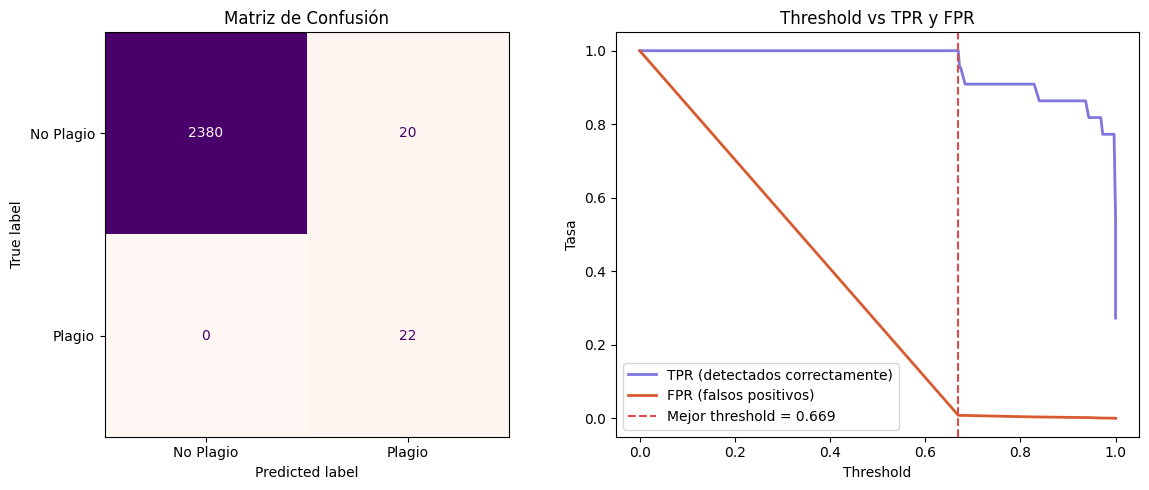

In [244]:
# Evaluar sobre test
y_proba = model.predict(X_test, verbose=0).ravel()

# Curva ROC y mejor threshold (estadístico J de Youden = TPR - FPR máximo)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
print(f"Mejor threshold (ROC): {best_threshold:.4f}")

y_pred = (y_proba >= best_threshold).astype(int)

print("\n=== Classification Report (test original) ===")
print(classification_report(y_test, y_pred, target_names=["No Plagio", "Plagio"]))

# Gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["No Plagio", "Plagio"]
).plot(
    ax=axes[0],
    cmap="RdPu",
    colorbar=False
)
axes[0].set_title("Matriz de Confusión")

axes[1].plot(thresholds[1:], tpr[1:], color="#7F77DD", lw=2, label="TPR (detectados correctamente)")
axes[1].plot(thresholds[1:], fpr[1:], color="#D85A30", lw=2, label="FPR (falsos positivos)")
axes[1].axvline(x=best_threshold, color="#E24B4A", linestyle="--", lw=1.5, label=f"Mejor threshold = {best_threshold:.3f}")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Tasa")
axes[1].set_title("Threshold vs TPR y FPR")
axes[1].legend()

plt.tight_layout()
plt.show()

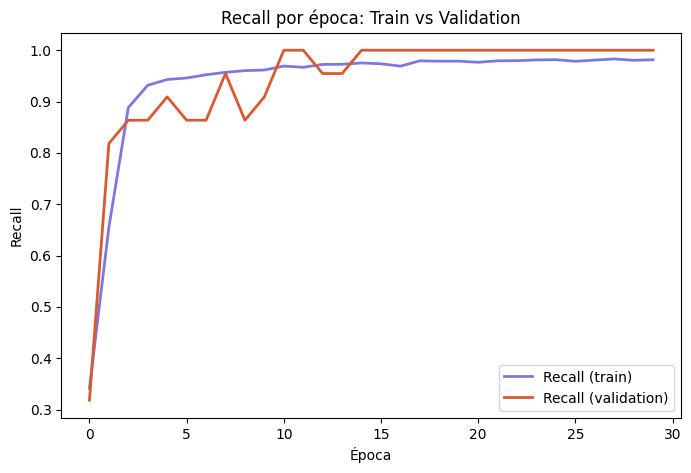

In [247]:
# ── Gráfica de Recall: Train vs Test (validación) por época ────────────────
plt.figure(figsize=(8, 5))
plt.plot(history.history['recall'], color="#7F77DD", lw=2, label="Recall (train)")
plt.plot(history.history['val_recall'], color="#D85A30", lw=2, label="Recall (validation)")
plt.xlabel("Época")
plt.ylabel("Recall")
plt.title("Recall por época: Train vs Validation")
plt.legend()
plt.show()

In [245]:
from sklearn.metrics import accuracy_score

print("Accuracy en Test:", accuracy_score(y_test, y_pred))

Accuracy en Test: 0.9917423616845582
